In [1]:
import pandas as pd
import numpy as np
import json
import re
import pickle
import ast
import seaborn as sns
import matplotlib.pyplot as plt
import category_encoders as ce

from scipy import stats
from scipy.stats import kruskal
from scipy.stats import mannwhitneyu
from sklearn.feature_selection import f_classif

## Знакомство с данными

In [2]:
hotels = pd.read_csv('data/hotels.csv')
hotels.head(3)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,10/18/2016,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643


In [3]:
hotels.describe()

,additional_number_of_scoring,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,lat,lng
count,386803.000000,386803.000000,386803.000000,386803.000000,386803.000000,386803.00000,386803.000000,384355.000000,384355.000000
mean,498.246536,8.397231,18.538988,2743.992042,17.776985,7.17725,8.396906,49.443522,2.823402
std,500.258012,0.547881,29.703369,2316.457018,21.726141,11.05442,1.636090,3.466936,4.579043
min,1.000000,5.200000,0.000000,43.000000,0.000000,1.00000,2.500000,41.328376,-0.369758
25%,169.000000,8.100000,2.000000,1161.000000,5.000000,1.00000,7.500000,48.214662,-0.143649
50%,342.000000,8.400000,9.000000,2134.000000,11.000000,3.00000,8.800000,51.499981,-0.000250
75%,660.000000,8.800000,23.000000,3613.000000,22.000000,8.00000,9.600000,51.516288,4.834443
max,2682.000000,9.800000,408.000000,16670.000000,395.000000,355.00000,10.000000,52.400181,16.429233


1. Средняя оценка по отелям приблизительно 8.4  
2. Минимальная оценка 5.2  
3. Максимальная оценка 9.8  
4. В среднем отрицательный отзыв состоит из 18 слов  
5. Максимальная длина отрицательного отзыва 408 слова  
6. Положительные отзывы незначительно отличаются по статистике от отрицательных  
7. В среднем рецензент оставляет 7 отзывов по отелям  
8. В среднем у отеля 2743 отзыва  
9. Максимум у отеля 16670 отзывов (что указывает на выброс, который нужно будет исследовать)  

In [4]:
hotels.describe(include=[object, 'str'])

,hotel_address,review_date,hotel_name,reviewer_nationality,negative_review,positive_review,tags,days_since_review
count,386803,386803,386803,386803,386803,386803,386803,386803
unique,1493,731,1492,225,248828,311737,47135,731
top,163 Marsh Wall Docklands Tower Hamlets London ...,8/2/2017,Britannia International Hotel Canary Wharf,United Kingdom,No Negative,No Positive,"[' Leisure trip ', ' Couple ', ' Double Room '...",1 days
freq,3587,1911,3587,184033,95907,26885,3853,1911


1. Самая популярная дата для отзыва 8 февраля 2017 года (что возможно говорит о том, что большинство отзывов оставляют в отпуске)  
2. Большинство рецензентов имеют Английское гражданство (United Kingdom)  
3. Большинство рецезентов ставят оценку, но не оствляют отзывов (Об этом говорят топовые значения "No Negative", "No Positive")  
4. Время обработки отзыва в основном 1 день  

In [5]:
hotels['review_date'] = pd.to_datetime(hotels['review_date'])

In [6]:
hotels['review_month'] = hotels.review_date.dt.month

In [7]:
hotels['review_year'] = hotels.review_date.dt.year

In [8]:
def shapiro_test(data, threshold=0.05):
    stat, p_value = stats.shapiro(data)
    if p_value > threshold:
        print("Данные распределены нормально")
    else:
        print("Данные распределены не нормально")

Посмотрим на информацию об оценках по году и месяцу рецензии.  

In [9]:
hotels.groupby(['review_year', 'review_month'])['reviewer_score'].median().round(2).unstack()

review_month,1,2,3,4,5,6,7,8,9,10,11,12
review_year,,,,,,,,,,,,
2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.8,8.8,8.8,8.8,8.8
2016,9.2,9.2,9.2,8.8,8.8,8.8,8.8,8.8,8.8,8.8,8.8,8.8
2017,9.2,9.2,8.8,8.8,8.8,8.8,8.8,8.8,NaN,NaN,NaN,NaN


Если взять медианы, то мы видим, что в первые три месяца оценки выше, чем в остальные.  
Можно выделить из этого отдельный признак.  
Построим нулевую и альтернативную гипотезу.  
Нулевая гипотеза: оценки в первые три месяца не отличаются статистически от оценок в остальные месяцы   
Альтернативная гипотеза: оценки в первые три месяца отличаются от оценок остальных месяцев  

In [10]:
first_three_months_groups = hotels[hotels['review_month'].isin([1, 2, 3])]
other_months_groups = hotels[~hotels['review_month'].isin([1, 2, 3])]

In [11]:
shapiro_test(first_three_months_groups['reviewer_score'])

Данные распределены не нормально


c:\Dev\SkillFactory\PROJECT-3.EDA_+_Feature Engineering\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 91148.
  res = hypotest_fun_out(*samples, **kwds)


In [12]:
shapiro_test(other_months_groups['reviewer_score'])

Данные распределены не нормально


c:\Dev\SkillFactory\PROJECT-3.EDA_+_Feature Engineering\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 295655.
  res = hypotest_fun_out(*samples, **kwds)


Так как данные в группа распределены не нормально и они независимы, применяем критерий Краскела-Уоллиса

In [13]:
_, p = kruskal(first_three_months_groups['reviewer_score'], other_months_groups['reviewer_score'])

In [14]:
if p > 0.05:
    print("У нас нет оснований отвергнуть нулевую гипотезу")
else:
    print("Отвергаем нулевую гипотезу в пользу альтернативной")

Отвергаем нулевую гипотезу в пользу альтернативной


Альтернативная гипотеза подтвердилась, спроектируем новый признак для первых трёх месяцев.

In [15]:
hotels['is_first_months'] = hotels['review_month'].isin([1, 2, 3])

Проанализируем теги

In [16]:
hotels_unique_tags = set()
for tags in hotels['tags']:
    if pd.notna(tags):
        tags_list = ast.literal_eval(tags)
        tags_list = [tag.strip() for tag in tags_list]
        hotels_unique_tags.update(tags_list)

In [17]:
tags_count = {}
for tags in hotels['tags']:
    if pd.notna(tags):
        tags_list = ast.literal_eval(tags)
        tags_list = [tag.strip() for tag in tags_list]
        for tag in tags_list:
            if tag in tags_count:
                tags_count[tag] += 1
            else:
                tags_count[tag] = 1

In [18]:
tags_count_df = pd.DataFrame(list(tags_count.items()), columns=['Tag', 'Count'])
tags_count_df = tags_count_df.sort_values(by='Count', ascending=False)

In [19]:
tags_count_df.head(50)

,Tag,Count
0,Leisure trip,313593
4,Submitted from a mobile device,230778
1,Couple,189212
7,Stayed 1 night,145373
3,Stayed 2 nights,100263
8,Solo traveler,81235
10,Stayed 3 nights,72000
5,Business trip,61989
25,Group,49088
20,Family with young children,45836


Отсюда можно выделить несколько категорий: "поездка для отдыха", "поездка парой", "поездка в одиночку", "групповая поездка", "семья с детьми".  
А так же отсюда можно получить информацию о типе комнаты.

In [20]:
hotels['tags_list'] = hotels['tags'].apply(ast.literal_eval)
hotels['tags_list'] = hotels['tags_list'].apply(lambda tags: [tag.strip() for tag in tags])

Проанализируем типы комнат

In [21]:
def get_room_type(tags):
    room_types = ['single', 'double', 'twin',
                  '2 rooms', 'queen', 'king',
                  'triple', 'guest', 'quadruple',
                  'family', 'comfort', 'one bedroom',
                  'standard', '3 rooms', 'luxury',
                  'camper', 'large', 'wonderful',
                  'club', 'superior', 'city',
                  'mini', 'ordinary', '4 rooms'
    ]
    
    for tag in tags:
        for room_type in room_types:
            if room_type in tag.lower():
                return room_type
    return 'other'

In [22]:
# hotels['room_type'] = hotels['tags_list'].apply(get_room_type)

In [23]:
# hotels['room_type'].value_counts()

In [24]:
# hotels.groupby('room_type')['reviewer_score'].median().sort_values(ascending=False).round(2)

Анализ показывает, что разные типы комнат оценивают по разному. Проверим так ли это.  
Нулевая гипотеза: Оценки по разными типам комнат не отличаются.  
Альтернативная гипотеза: Оценки различаются для разных типов комнат.  

In [25]:
# room_types = hotels['room_type'].unique()

# for room_type in room_types:
#     shapiro_test(hotels[hotels['room_type'] == room_type]['reviewer_score'])

Видим, что почти все группы имеют не нормальное распределение данных. Используем тест Краскела-Уоллиса.

In [26]:
# room_types_groups = [hotels[hotels['room_type'] == room_type]['reviewer_score'] for room_type in room_types]
# _, p = kruskal(*room_types_groups)

# if p > 0.05:
#     print("У нас нет оснований отвергнуть нулевую гипотезу")
# else:
#     print("Отвергаем нулевую гипотезу в пользу альтернативной")

## Проектирование признаков

Подгрузим специальный файл с названиями стран и их столицами.

In [27]:
hotel_locations = json.load(open('data/hotel_locations.json'))
hotel_locations

[{'country': 'United Kingdom', 'capital': 'London'},
 {'country': 'France', 'capital': 'Paris'},
 {'country': 'Netherlands', 'capital': 'Amsterdam'},
 {'country': 'Italy', 'capital': 'Rome'},
 {'country': 'Austria', 'capital': 'Vienna'},
 {'country': 'Spain', 'capital': 'Madrid'}]

In [28]:
def find_country(address):
    country_part = address.split()[-1]
    for item in hotel_locations:
        if country_part in item['country']:
            return item['country']
    return 'Unknown'

In [29]:
def find_capital(address):
    country_part = address.split()[-1]
    for item in hotel_locations:
        if country_part in item['country']:
            return item['capital']
    return 'Unknown'

In [30]:
hotels['hotel_country'] = hotels['hotel_address'].apply(find_country)

In [31]:
hotels['hotel_country'].unique()

<StringArray>
['United Kingdom', 'France', 'Netherlands', 'Italy', 'Austria', 'Spain']
Length: 6, dtype: str

In [32]:
hotels['hotel_capital'] = hotels['hotel_address'].apply(find_capital)

In [33]:
hotels['hotel_capital'].unique()

<StringArray>
['London', 'Paris', 'Amsterdam', 'Rome', 'Vienna', 'Madrid']
Length: 6, dtype: str

<Axes: xlabel='hotel_country', ylabel='reviewer_score'>

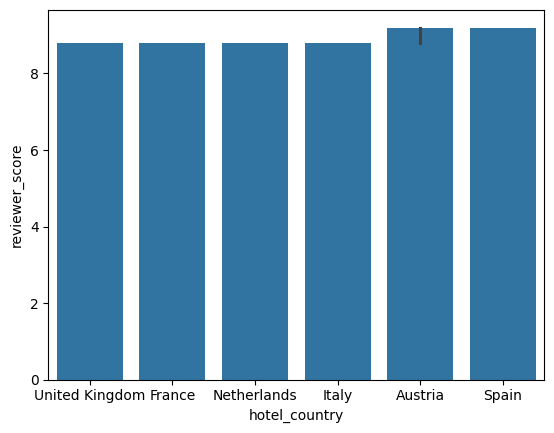

In [34]:
sns.barplot(x='hotel_country', y='reviewer_score', data=hotels, estimator=np.median)

Как видно, медианные оценки для отелей в странах Австралия и Испания выше остальных.  
Проверим различаются ли оценки в зависимости от страны.  
Нулевая гипотеза: Оценки отеля не отличаются в разных странах.  
Альтернативная гипотеза: Оценки отеля для разных стран отличаются.  

In [35]:
for hotel_country in hotels['hotel_country'].unique():
    shapiro_test(hotels[hotels['hotel_country'] == hotel_country]['reviewer_score'])

Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально


c:\Dev\SkillFactory\PROJECT-3.EDA_+_Feature Engineering\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 196774.
  res = hypotest_fun_out(*samples, **kwds)
c:\Dev\SkillFactory\PROJECT-3.EDA_+_Feature Engineering\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 44830.
  res = hypotest_fun_out(*samples, **kwds)
c:\Dev\SkillFactory\PROJECT-3.EDA_+_Feature Engineering\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 43006.
  res = hypotest_fun_out(*samples, **kwds)
c:\Dev\SkillFactory\PROJECT-3.EDA_+_Feature Engineering\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate

Данные не распределены нормально для всех выборок, и эти выборки не связаны, поэтому применяем критерий Краскела-Уоллиса.

In [36]:
hotel_country_groups = [hotels[hotels['hotel_country'] == hotel_country]['reviewer_score'] for hotel_country in hotels['hotel_country'].unique()]
_, p = kruskal(*hotel_country_groups)

if p > 0.05:
    print("У нас нет оснований отвергнуть нулевую гипотезу")
else:
    print("Отвергаем нулевую гипотезу в пользу альтернативной")

Отвергаем нулевую гипотезу в пользу альтернативной


Добавим информацию о районах. Для этого я создал специальный файл сопоставлений: адрес отеля -> район.

In [38]:
address_dict_df = pd.read_csv('data/address_dict_df.csv')

In [39]:
address_dict = dict(zip(address_dict_df['hotel_address'], address_dict_df['country']))

In [40]:
hotels['hotel_district'] = hotels['hotel_address'].map(address_dict)

In [41]:
hotels.groupby('hotel_district')['reviewer_score'].median().sort_values(ascending=False).round(2)

hotel_district
Victoria                    10.0
l'Odeon                      9.8
Barri Gotic                  9.6
Acton                        9.6
Broadgate                    9.6
                            ... 
Quartiere Ca' Granda Sud     7.5
St Dunstan's                 7.5
Lorenteggio                  6.9
Bridge                       6.7
Church Street                6.3
Name: reviewer_score, Length: 241, dtype: float64

Проверим, отличаются ли оценки для районов.  
H0: Оценки для разных районов не отличаются.  
H1: Оценки для разных районов отличаются.  

In [42]:
for hotel_district in hotels['hotel_district'].unique():
    shapiro_test(hotels[hotels['hotel_district'] == hotel_district]['reviewer_score'])

Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально


c:\Dev\SkillFactory\PROJECT-3.EDA_+_Feature Engineering\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 13524.
  res = hypotest_fun_out(*samples, **kwds)
c:\Dev\SkillFactory\PROJECT-3.EDA_+_Feature Engineering\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 44263.
  res = hypotest_fun_out(*samples, **kwds)
c:\Dev\SkillFactory\PROJECT-3.EDA_+_Feature Engineering\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5731.
  res = hypotest_fun_out(*samples, **kwds)


Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально


c:\Dev\SkillFactory\PROJECT-3.EDA_+_Feature Engineering\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 13937.
  res = hypotest_fun_out(*samples, **kwds)
c:\Dev\SkillFactory\PROJECT-3.EDA_+_Feature Engineering\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9216.
  res = hypotest_fun_out(*samples, **kwds)
c:\Dev\SkillFactory\PROJECT-3.EDA_+_Feature Engineering\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 23193.
  res = hypotest_fun_out(*samples, **kwds)


Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально


...

Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально


c:\Dev\SkillFactory\PROJECT-3.EDA_+_Feature Engineering\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6780.
  res = hypotest_fun_out(*samples, **kwds)
c:\Dev\SkillFactory\PROJECT-3.EDA_+_Feature Engineering\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5946.
  res = hypotest_fun_out(*samples, **kwds)
c:\Dev\SkillFactory\PROJECT-3.EDA_+_Feature Engineering\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7642.
  res = hypotest_fun_out(*samples, **kwds)


Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально


c:\Dev\SkillFactory\PROJECT-3.EDA_+_Feature Engineering\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 14249.
  res = hypotest_fun_out(*samples, **kwds)


Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные рас

Видим, что данные не в основном не распределены нормально, поэтому применяем критерий Краскела-Уоллиса.

In [43]:
hotel_district_groups = [hotels[hotels['hotel_district'] == hotel_district]['reviewer_score'] for hotel_district in hotels['hotel_district'].unique()]
_, p = kruskal(*hotel_district_groups)

In [44]:
if p > 0.05:
    print("У нас нет оснований отвергнуть нулевую гипотезу")
else:
    print("Отвергаем нулевую гипотезу в пользу альтернативной")

Отвергаем нулевую гипотезу в пользу альтернативной


Поработаем с адресами отелей и выделим из них города отелей.

In [45]:
def get_hotel_city(row):
    cities = [
        'London',
        'Paris',
        'Amsterdam',
        'Milan',
        'Vienna',
        'Barcelona',
    ]
    
    regex_pattern = re.compile(r'\b(' + '|'.join(re.escape(city) for city in cities) + r')\b', re.IGNORECASE)
    
    city_match = regex_pattern.findall(row['hotel_address'])
    
    if city_match:
        return city_match[-1]
    
    return 'Unknown'

In [46]:
hotels['hotel_city'] = hotels.apply(get_hotel_city, axis=1)

<Axes: xlabel='hotel_city', ylabel='Count'>

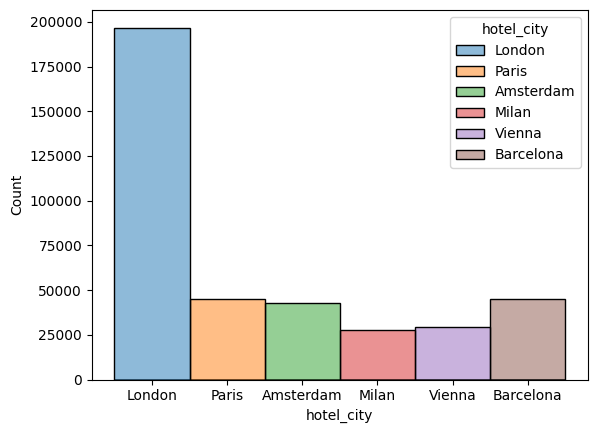

In [47]:
sns.histplot(data=hotels, x='hotel_city', hue='hotel_city', kde=True)

Поработаем с адресами отелей, выделим из них индексы.

In [48]:
def get_postcode(row):
    # Регулярки для почтовых индексов разных стран
    postal_patterns = {
        "United Kingdom": r"\b([A-Z]{1,2}\d[A-Z\d]?\s?\d[A-Z]{2})\b",
        "France": r"\b(\d{5})\b",
        "Netherlands": r"\b(\d{4}\s?[A-Z]{2})\b",
        "Italy": r"\b(\d{5})\b",
        "Austria": r"\b(\d{4})\b",
        "Spain": r"\b(\d{5})\b",
    }
    
    address = row['hotel_address']
    
    for country in postal_patterns.keys():
        if address.endswith(country):
            pattern = postal_patterns[country]
            match = re.search(pattern, address)
            if match:
                return match.group(1)
            
    return np.nan

In [49]:
hotels['postcode'] = hotels.apply(get_postcode, axis=1)

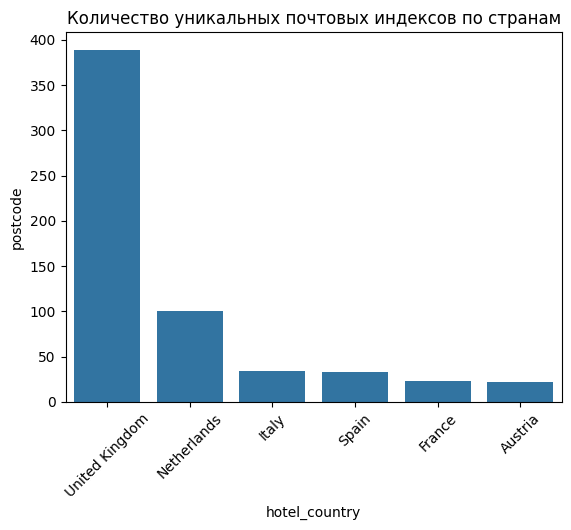

In [50]:
sns.barplot(data=hotels.groupby('hotel_country')['postcode'].nunique().reset_index().sort_values('postcode', ascending=False), x='hotel_country', y='postcode')
plt.title('Количество уникальных почтовых индексов по странам')
plt.xticks(rotation=45)
plt.show()

Из анализа видно что в Великобритании и Нидерландах большое количество почтовых индексов. Попробуем их сократить.  
В Великобритании есть outward code - это первая часть почтового индекса, которая находится до пробела. Она предназначена для первичной сортировки почты и указывает на город, район или почтовый регион.  
Если мы оставим только эту часть это будет хорошим компромиссом. Так как мы всё-равно сохраняем основную информацию о местоположении и при этом сокращаем размер выборки.  

In [51]:
mask = hotels['hotel_country'] == 'United Kingdom'

hotels.loc[mask, 'postcode'] = (
    hotels.loc[mask, 'postcode']
    .str.extract(r'^([A-Z]{1,2}\d[A-Z\d]?)', expand=False)
)

In [52]:
hotels[hotels['hotel_country'] == 'United Kingdom']['postcode'].nunique()

91

Для Великобритании мы сниизили количество почтовых адресов с 389 до 91, неплохо.

Для Нидерландов достаточно первых четырёх цифр почтового индекса, что бы определить район города. Воспользуемся этим.

In [53]:
mask = hotels['hotel_country'] == 'Netherlands'

hotels.loc[mask, 'postcode'] = (
    hotels.loc[mask, 'postcode']
    .str.extract(r'^(\d{4})', expand=False)
)

In [54]:
hotels[hotels['hotel_country'] == 'Netherlands']['postcode'].nunique()

37

Для Нидерландов мы снизили количество почтовых адресов со ста до 37. Что тоже неплохо. 

Проверим влияние почтовых индексов на оценку отеля.

In [55]:
hotels.groupby(['hotel_country', 'postcode'])['reviewer_score'].median().sort_values(ascending=False).round(2).head(10)

hotel_country   postcode
Austria         1015        9.6
Netherlands     1015        9.6
                1067        9.6
                1016        9.6
United Kingdom  SW1Y        9.6
                WC1V        9.6
                WC2E        9.6
                W1D         9.6
                SE10        9.6
                EC1V        9.6
Name: reviewer_score, dtype: float64

In [56]:
hotels.groupby(['hotel_country', 'postcode'])['reviewer_score'].median().sort_values(ascending=False).round(2).tail(10)

hotel_country   postcode
Italy           20146       7.5
                20159       7.5
United Kingdom  W9          7.5
                NW6         7.5
Spain           08023       7.5
Italy           20153       7.1
United Kingdom  IG8         7.1
Italy           20158       7.1
United Kingdom  WC1E        7.1
Italy           20152       6.9
Name: reviewer_score, dtype: float64

Быстрый анализ показывает, что различия в оценке по индексам есть. Проверим это.  
H0: Для всех почтовых индексов внутри страны оценка статистически не отличается.  
H1: Хотя бы для одного индекса внутри страны оценка отличается.  

Так как групп очень много, воспользуемся визуализацией.

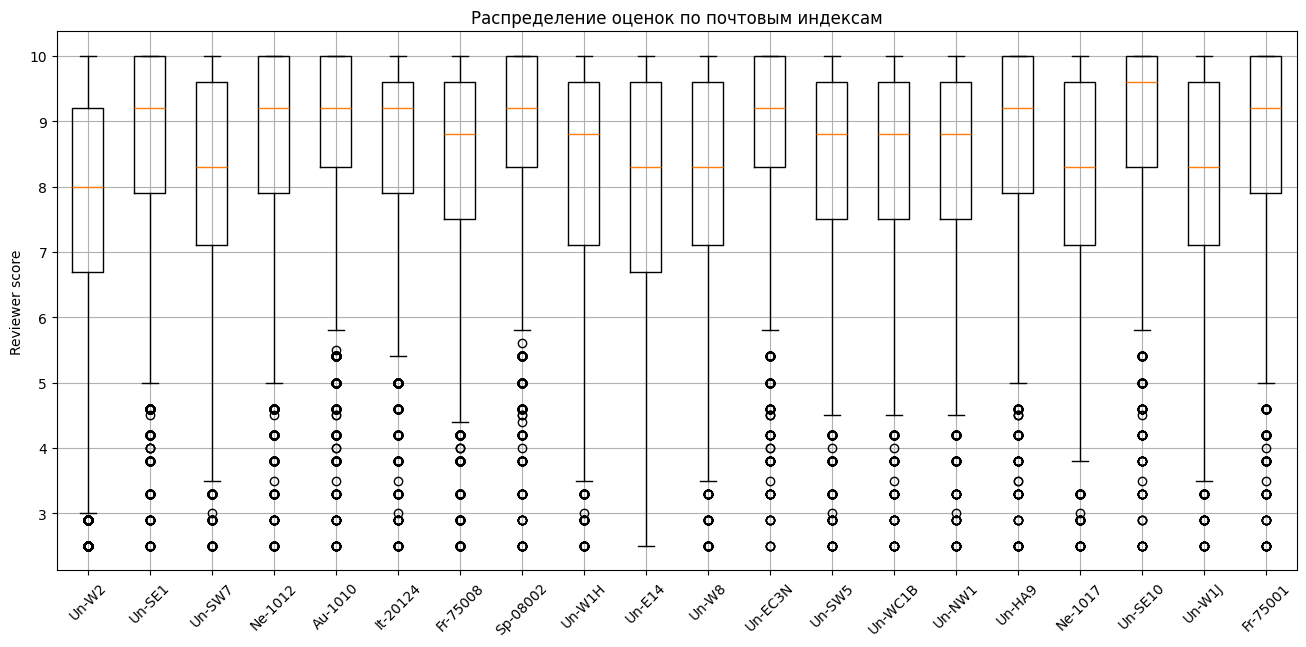

In [57]:
# Берём только postcode с достаточным количеством наблюдений
valid_postcodes = (
    hotels.groupby(['hotel_country', 'postcode'])
    .size()
    .loc[lambda x: x >= 100]
    .index
)

filtered = (
    hotels.set_index(['hotel_country', 'postcode'])
    .loc[valid_postcodes]
    .reset_index()
)

# Топ-20 postcode по количеству записей
top_postcodes = (
    filtered.groupby(['hotel_country', 'postcode'])
    .size()
    .sort_values(ascending=False)
    .head(20)
    .index
)

plot_data = []
labels = []

for postcode_key in top_postcodes:
    country, postcode = postcode_key

    scores = filtered[
        (filtered['hotel_country'] == country) &
        (filtered['postcode'] == postcode)
    ]['reviewer_score']

    plot_data.append(scores)
    labels.append(f'{country[:2]}-{postcode}')

plt.figure(figsize=(16, 7))

plt.boxplot(plot_data, tick_labels=labels)

plt.xticks(rotation=45)

plt.ylabel('Reviewer score')
plt.title('Распределение оценок по почтовым индексам')

plt.grid(True)

plt.show()

Видим, что почтовые индексы влияют на оценку пользователей.

Заполним недостающие координаты отелей. Для этого воспользуемся специальным файлом в котором с помощью специальных сервисов я собрал данные по координатам для разных отелей.  

In [58]:
empty_lat_lng = hotels[(hotels['lat'].isna()) | (hotels['lng'].isna())]

In [62]:
coords_dict_df = pd.read_csv('data/coords_dict_df.csv')

In [63]:
coords_dict = {
    row['hotel_address']: ast.literal_eval(row['coords'])
    for index, row in coords_dict_df.iterrows()
}

In [64]:
for index, row in empty_lat_lng.iterrows():
    coords = coords_dict.get(row['hotel_address'])
    
    if coords:
        hotels.at[index, 'lat'] = coords[0]
        hotels.at[index, 'lng'] = coords[1]

Посмотрим на количество городов.

In [65]:
len(hotels['hotel_city'].unique())

6

У нас всего шесть городов. Поэтому мы вручную можем добавить информацию о координатах центра каждого города.

In [66]:
hotels['hotel_city'].unique()

<StringArray>
['London', 'Paris', 'Amsterdam', 'Milan', 'Vienna', 'Barcelona']
Length: 6, dtype: str

In [67]:
cities_center_coords = {
    'Paris': (48.8566, 2.3522),
    'London': (51.5074, -0.1278),
    'Amsterdam': (52.3676, 4.9041),
    'Milan': (45.464211, 9.191383),
    'Vienna': (48.2082, 16.3738),
    'Barcelona': (41.3899, 2.1700)
}

Посчитаем расстояния отелей до центра.

In [68]:
from geopy.distance import geodesic

def calculate_distance(row):
    city = row['hotel_city']
    if city in cities_center_coords and pd.notna(row['lat']) and pd.notna(row['lng']):
        hotel_coords = (row['lat'], row['lng'])
        city_coords = cities_center_coords[city]
        return geodesic(hotel_coords, city_coords).km
    return np.nan

In [69]:
hotels['distance_to_city_center'] = hotels.apply(calculate_distance, axis=1)

In [70]:
hotels['distance_to_city_center'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    386803.000000
mean          3.152768
std           2.557476
min           0.038345
50%           2.471418
75%           4.088286
90%           6.560107
95%           8.576040
99%          12.168961
max          17.189438
Name: distance_to_city_center, dtype: float64

Как видно по описательному анализу мы получили адекватные значения для расстояний до центра.

Посмотрим на национальность рецензентов

In [71]:
hotels['reviewer_nationality'].nunique()

225

У нас 225 уникальных значений, что много. Попробуем объеденить страны по частам света.

In [72]:
country_to_region = {
    'United Kingdom': 'Европа',
    'China': 'Азия',
    'Poland': 'Европа',
    'France': 'Европа',
    'Switzerland': 'Европа',
    'Bulgaria': 'Европа',
    'Lebanon': 'Азия',
    'United Arab Emirates': 'Азия',
    'South Africa': 'Африка',
    'Nigeria': 'Африка',
    'Sweden': 'Европа',
    'United States of America': 'Северная Америка',
    'Hong Kong': 'Азия',
    'Luxembourg': 'Европа',
    'Netherlands': 'Европа',
    'Jersey': 'Европа',
    'Pakistan': 'Азия',
    'Mexico': 'Северная Америка',
    'Italy': 'Европа',
    'Singapore': 'Азия',
    'Ireland': 'Европа',
    'Kuwait': 'Азия',
    'Bahrain': 'Азия',
    'Portugal': 'Европа',
    'Canada': 'Северная Америка',
    'Germany': 'Европа',
    'Oman': 'Азия',
    'Austria': 'Европа',
    'Japan': 'Азия',
    'Ukraine': 'Европа',
    'Finland': 'Европа',
    'Iran': 'Азия',
    'Thailand': 'Азия',
    'Brazil': 'Южная Америка',
    'Denmark': 'Европа',
    'Australia': 'Австралия и Океания',
    'Spain': 'Европа',
    'Gabon': 'Африка',
    'New Zealand': 'Австралия и Океания',
    'Israel': 'Азия',
    'Cyprus': 'Европа',
    'Gibraltar': 'Европа',
    'Turkey': 'Азия',
    'Egypt': 'Африка',
    'Indonesia': 'Азия',
    'Slovakia': 'Европа',
    'Qatar': 'Азия',
    'Romania': 'Европа',
    'Belgium': 'Европа',
    'Trinidad and Tobago': 'Северная Америка',
    'Saudi Arabia': 'Азия',
    'Bhutan': 'Азия',
    'Iceland': 'Европа',
    'Norway': 'Европа',
    'Sri Lanka': 'Азия',
    'Greece': 'Европа',
    'Slovenia': 'Европа',
    'Serbia': 'Европа',
    'Czech Republic': 'Европа',
    'Hungary': 'Европа',
    'Latvia': 'Европа',
    'Estonia': 'Европа',
    'South Korea': 'Азия',
    'Malaysia': 'Азия',
    'Malta': 'Европа',
    'Bosnia and Herzegovina': 'Европа',
    'Jordan': 'Азия',
    'Chile': 'Южная Америка',
    'India': 'Азия',
    'Vietnam': 'Азия',
    'Puerto Rico': 'Северная Америка',
    'Russia': 'Европа',
    'Colombia': 'Южная Америка',
    'Georgia': 'Азия',
    'Argentina': 'Южная Америка',
    'Kazakhstan': 'Азия',
    'Croatia': 'Европа',
    'Lithuania': 'Европа',
    'Montenegro': 'Европа',
    'Costa Rica': 'Северная Америка',
    'Mauritius': 'Африка',
    'Fiji': 'Австралия и Океания',
    'Philippines': 'Азия',
    'Peru': 'Южная Америка',
    'Belarus': 'Европа',
    'Morocco': 'Африка',
    'Azerbaijan': 'Азия',
    'Venezuela': 'Южная Америка',
    'Taiwan': 'Азия',
    'Ghana': 'Африка',
    'Paraguay': 'Южная Америка',
    'Macedonia': 'Европа',
    'Panama': 'Северная Америка',
    'Guatemala': 'Северная Америка',
    'Ecuador': 'Южная Америка',
    'Kenya': 'Африка',
    'Iraq': 'Азия',
    'Bangladesh': 'Азия',
    'Zimbabwe': 'Африка',
    'Armenia': 'Азия',
    'Albania': 'Европа',
    'Namibia': 'Африка',
    'Libya': 'Африка',
    'Moldova': 'Европа',
    'Bolivia': 'Южная Америка',
    'Tanzania': 'Африка',
    'Mali': 'Африка',
    'Tunisia': 'Африка',
    'Algeria': 'Африка',
    'Mongolia': 'Азия',
    'Madagascar': 'Африка',
    'Nicaragua': 'Северная Америка',
    'Zambia': 'Африка',
    'Ethiopia': 'Африка',
    'Ivory Coast': 'Африка',
    'Senegal': 'Африка',
    'Jamaica': 'Северная Америка',
    'Belize': 'Северная Америка',
    'Angola': 'Африка',
    'Myanmar': 'Азия',
    'Honduras': 'Северная Америка',
    'Maldives': 'Азия',
    'Uganda': 'Африка',
    'Yemen': 'Азия',
    'Uruguay': 'Южная Америка',
    'Benin': 'Африка',
    'Palestinian Territory': 'Азия',
    'Botswana': 'Африка',
    'Suriname': 'Южная Америка',
    'Malawi': 'Африка',
    'Niger': 'Африка',
    'Djibouti': 'Африка',
    'Mozambique': 'Африка',
    'Guinea': 'Африка',
    'Cambodia': 'Азия',
    'Dominican Republic': 'Северная Америка',
    'Turkmenistan': 'Азия',
    'Laos': 'Азия',
    'Crimea': 'Европа',
    'Congo': 'Африка',
    'Liberia': 'Африка',
    'Uzbekistan': 'Азия',
    'Kyrgyzstan': 'Азия',
    'Nepal': 'Азия',
    'Tajikistan': 'Азия',
    'Haiti': 'Северная Америка',
    'Sierra Leone': 'Африка',
    'Swaziland': 'Африка',
    'Vanuatu': 'Австралия и Океания',
    'Afghanistan': 'Азия',
    'Samoa': 'Австралия и Океания',
    'Guyana': 'Южная Америка',
    'South Sudan': 'Африка',
    'Kiribati': 'Австралия и Океания',
    'Somalia': 'Африка',
    'Democratic Republic of the Congo': 'Африка',
    'Eritrea': 'Африка',
    'San Marino': 'Европа',
    'Cameroon': 'Африка',
    'East Timor': 'Азия',
    'Palau': 'Австралия и Океания',
    'Grenada': 'Северная Америка',
    '': 'Unknown',
}

In [73]:
hotels['reviewer_region'] = hotels['reviewer_nationality'].str.strip().map(country_to_region)

In [74]:
hotels['reviewer_region'] = hotels['reviewer_region'].fillna('Unknown')

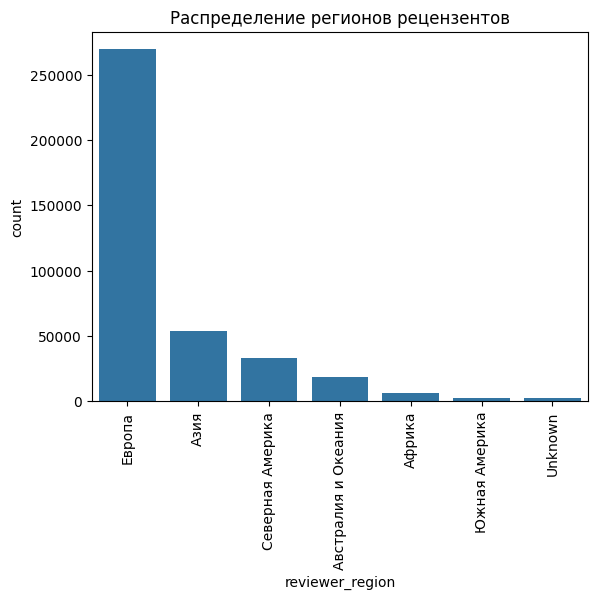

In [75]:
sns.countplot(data=hotels, x='reviewer_region', order=hotels['reviewer_region'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Распределение регионов рецензентов')
plt.show()

In [76]:
hotels.groupby('reviewer_region')['reviewer_score'].median().sort_values(ascending=False).round(2)

reviewer_region
Австралия и Океания    9.2
Северная Америка       9.2
Unknown                8.8
Европа                 8.8
Африка                 8.8
Южная Америка          8.8
Азия                   8.3
Name: reviewer_score, dtype: float64

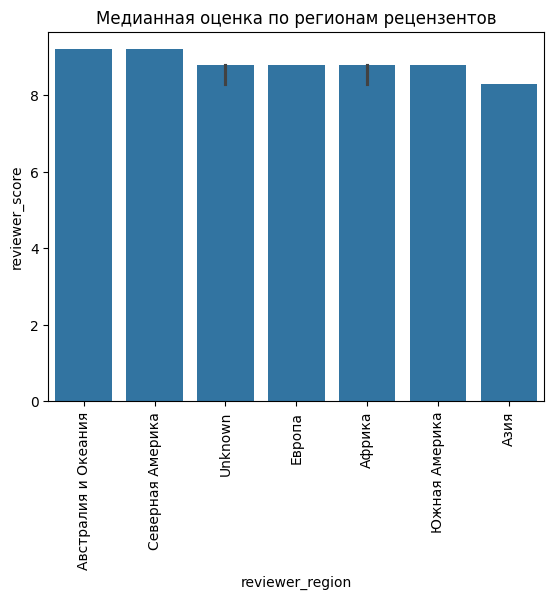

In [77]:
sns.barplot(data=hotels, x='reviewer_region', y='reviewer_score', estimator='median', order=hotels.groupby('reviewer_region')['reviewer_score'].median().sort_values(ascending=False).index)
plt.xticks(rotation=90)
plt.title('Медианная оценка по регионам рецензентов')
plt.show()

Видим, что Австралия и Океания и Северная Америка отличаются по оценкам. Давайте проверим это.  
H0: Оценки для разных частей света не отличаются.  
H1: Оценки для разных частей света отличаются.  

In [78]:
for reviewer_region in hotels['reviewer_region'].unique():
    shapiro_test(hotels[hotels['reviewer_region'] == reviewer_region]['reviewer_score'])

Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально
Данные распределены не нормально


c:\Dev\SkillFactory\PROJECT-3.EDA_+_Feature Engineering\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 269413.
  res = hypotest_fun_out(*samples, **kwds)
c:\Dev\SkillFactory\PROJECT-3.EDA_+_Feature Engineering\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 53695.
  res = hypotest_fun_out(*samples, **kwds)
c:\Dev\SkillFactory\PROJECT-3.EDA_+_Feature Engineering\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6690.
  res = hypotest_fun_out(*samples, **kwds)
c:\Dev\SkillFactory\PROJECT-3.EDA_+_Feature Engineering\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate.

In [79]:
reviewer_region_groups = [hotels[hotels['reviewer_region'] == reviewer_region]['reviewer_score'] for reviewer_region in hotels['reviewer_region'].unique()]
_, p = kruskal(*reviewer_region_groups)

if p > 0.05:
    print("У нас нет оснований отвергнуть нулевую гипотезу")
else:
    print("Отвергаем нулевую гипотезу в пользу альтернативной")

Отвергаем нулевую гипотезу в пользу альтернативной


Для начала поработаем с положительными отзывами. Для анализа отзывов я использовал claude. Я попросил его выделить самые популярные положительные моменты в отзывах. В итоге у нас такая картина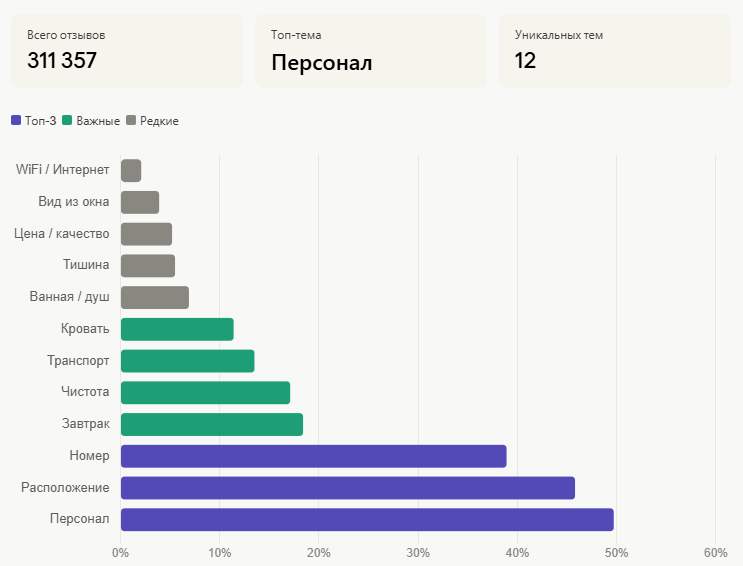

Давайте соберем для каждого такого момета признак.

In [80]:
THEMES = {
    "positive_location": [
        r"\blocation\b", r"\blocated\b", r"\bcentral\b",
        r"\bclose to\b", r"\bnear(by)?\b.*\b(station|metro|tube|center|centre)\b",
        r"\bminute[s]? walk\b", r"\bperfect location\b", r"\bgreat location\b",
        r"\bexcellent location\b", r"\bgood location\b",
    ],
    "positive_staff": [
        r"\bstaff\b", r"\breception(ist)?\b", r"\bfriendly\b",
        r"\bhelpful\b", r"\bkind\b", r"\bcourteous\b",
        r"\bwelcoming\b", r"\battentive\b", r"\bservice\b", r"\bprofessional\b",
    ],
    "positive_cleanliness": [
        r"\bclean(liness)?\b", r"\bspotless\b", r"\btidy\b", r"\bimmaculate\b",
    ],
    "positive_room": [
        r"\broom\b", r"\bspacious\b", r"\bcomfort(able)?\b",
        r"\bcozy\b", r"\bcosy\b", r"\bmodern\b", r"\bstylish\b",
    ],
    "positive_bed": [
        r"\bbed\b", r"\bpillow\b", r"\bcomfy bed\b", r"\bcomfortable bed\b",
    ],
    "positive_breakfast": [
        r"\bbreakfast\b", r"\bbrunch\b",
    ],
    "positive_transport": [
        r"\bmetro\b", r"\btube\b", r"\bunderground\b",
        r"\btrain station\b", r"\btram\b", r"\bbus stop\b",
        r"\btransport\b", r"\bstation\b",
    ],
    "positive_value": [
        r"\bvalue\b", r"\bprice\b", r"\baffordable\b",
        r"\bcheap\b", r"\bworth\b", r"\bvalue for money\b", r"\bgood deal\b",
    ],
    "positive_quiet": [
        r"\bquiet\b", r"\bpeaceful\b", r"\bsilent\b", r"\bno noise\b",
    ],
    "positive_wifi": [
        r"\bwifi\b", r"\bwi-fi\b", r"\binternet\b", r"\bwireless\b",
    ],
    "positive_bathroom": [
        r"\bbathroom\b", r"\bshower\b", r"\bbath\b",
    ],
    "positive_view": [
        r"\bview\b", r"\bscenic\b", r"\bpanorama\b", r"\boverloking\b",
    ],
}
 
# Предкомпилируем паттерны для скорости
COMPILED = {
    theme: [re.compile(p, re.IGNORECASE) for p in patterns]
    for theme, patterns in THEMES.items()
}

def classify_line(text: str) -> dict:
    """Возвращает словарь {тема: 0/1} для одного отзыва."""
    df = {theme: 0 for theme in THEMES.keys()}
    for theme, patterns in COMPILED.items():
        df[theme] = int(any(p.search(text) for p in patterns))
    return df

In [81]:
classification_results = hotels['positive_review'].apply(classify_line)

In [82]:
classification_df = pd.DataFrame(classification_results.tolist())

In [83]:
hotels = hotels.merge(classification_df, left_index=True, right_index=True)

In [84]:
hotels.groupby('positive_view')['reviewer_score'].mean().sort_values(ascending=False).round(2)

positive_view
1    8.80
0    8.38
Name: reviewer_score, dtype: float64

Теперь поработаем с негативными отзывами. Так же прогнал их через claude. Картина такая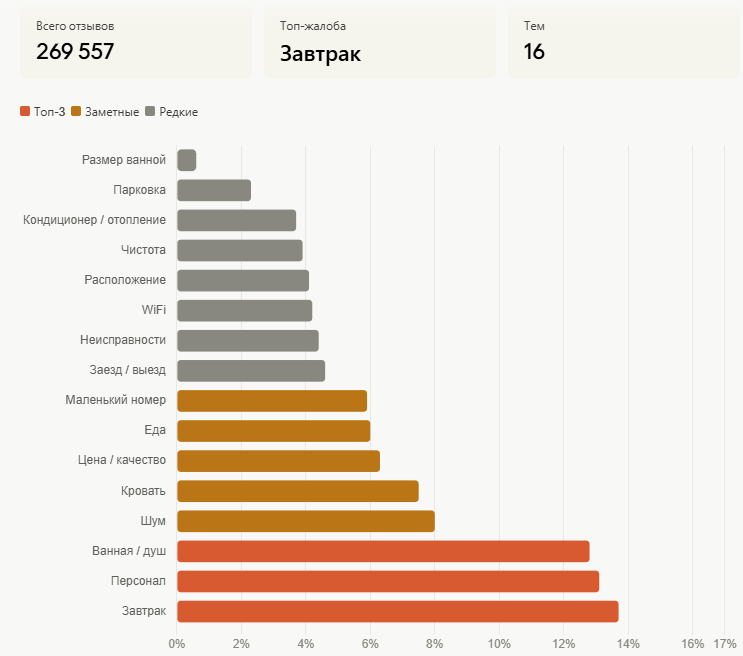

Создадим признак для кажой такой особенности.

In [85]:
# ─────────────────────────────────────────────────────────────────
# Паттерны "пустых" отзывов — фильтруются до классификации
# ─────────────────────────────────────────────────────────────────
SKIP_PATTERN = re.compile(
    r'^(no negative|nothing|n\s*/?\s*a|na|none|nil|not applicable)[\s.!]*$',
    re.IGNORECASE,
)
 
# ─────────────────────────────────────────────────────────────────
# Тематические признаки: имя_колонки → паттерны (негативный контекст)
# ─────────────────────────────────────────────────────────────────
THEMES = {
    "bad_breakfast": [
        r"\bbreakfast\b",
        r"\bbrunch\b",
    ],
    "bad_staff": [
        r"\bstaff\b",
        r"\breception(ist)?\b",
        r"\brude\b",
        r"\bunhelpful\b",
        r"\bunfriendly\b",
        r"\bignorant\b",
        r"\battitude\b",
        r"\bimpolite\b",
        r"\bnot helpful\b",
    ],
    "bad_bathroom": [
        r"\bbathroom\b",
        r"\bshower\b",
        r"\bbath\b",
        r"\btoilet\b",
        r"\bwater pressure\b",
        r"\bhot water\b",
        r"\bcold water\b",
    ],
    "bad_noise": [
        r"\bnois(e|y)\b",
        r"\bloud\b",
        r"\bdisturb\b",
        r"\bbang(ing)?\b",
        r"\bsound(proof)?\b",
        r"\bbar noise\b",
        r"\bstreet noise\b",
        r"\bsnor(e|ing)\b",
    ],
    "bad_bed": [
        r"\bbed\b",
        r"\bpillow\b",
        r"\bmattress\b",
        r"\bsheet(s)?\b",
        r"\buncomfortable bed\b",
        r"\bhard bed\b",
    ],
    "bad_value": [
        r"\bexpensive\b",
        r"\boverpriced\b",
        r"\bnot worth\b",
        r"\bpoor value\b",
        r"\btoo (much|dear|pricey)\b",
        r"\bhidden charge\b",
        r"\bextra charge\b",
    ],
    "bad_food": [
        r"\bfood\b",
        r"\bmeal\b",
        r"\bdining\b",
        r"\brestaurant\b",
        r"\blunch\b",
        r"\bdinner\b",
    ],
    "bad_small_room": [
        r"\bsmall room\b",
        r"\btiny room\b",
        r"\broom (too |was )?(small|tiny|cramped)\b",
        r"\bcramped\b",
        r"\bno space\b",
        r"\bvery small\b",
    ],
    "bad_checkin": [
        r"\bcheck.?in\b",
        r"\bcheck.?out\b",
        r"\bwait(ed|ing)\b",
        r"\bqueue\b",
        r"\blong wait\b",
    ],
    "bad_maintenance": [
        r"\bbroken\b",
        r"\bnot work(ing)?\b",
        r"\bfault(y)?\b",
        r"\brepair\b",
        r"\brefurb\b",
        r"\bmaintenance\b",
        r"\bout of order\b",
        r"\bdamaged\b",
    ],
    "bad_wifi": [
        r"\bwifi\b",
        r"\bwi-fi\b",
        r"\binternet\b",
        r"\bconnection\b",
    ],
    "bad_location": [
        r"\blocation\b",
        r"\bfar from\b",
        r"\bnot central\b",
        r"\bno transport\b",
        r"\bbad area\b",
        r"\baway from\b",
    ],
    "bad_cleanliness": [
        r"\bdirt(y)?\b",
        r"\bstain(ed|s)?\b",
        r"\bunclean\b",
        r"\bsmell\b",
        r"\bodour\b",
        r"\bmould\b",
        r"\bdusty\b",
        r"\bfilth(y)?\b",
        r"\bbug(s)?\b",
    ],
    "bad_aircon_heating": [
        r"\bair.?con(dition)?\b",
        r"\bheating\b",
        r"\btoo hot\b",
        r"\btoo cold\b",
        r"\bno (air|heat)\b",
        r"\btemperature\b",
    ],
    "bad_parking": [
        r"\bparking\b",
        r"\bcar park\b",
    ],
    "bad_size_bathroom": [
        r"\bsmall bathroom\b",
        r"\btiny bathroom\b",
        r"\bsmall shower\b",
        r"\bno bath\b",
    ],
}
 
# Предкомпилируем паттерны для скорости
COMPILED = {
    theme: [re.compile(p, re.IGNORECASE) for p in patterns]
    for theme, patterns in THEMES.items()
}
 
 
def is_empty_review(text: str) -> bool:
    """Возвращает True для пустых/нейтральных ответов типа 'No Negative', 'N/A'."""
    return bool(SKIP_PATTERN.match(text))
 
 
def classify_line(text: str) -> dict:
    """Возвращает словарь {тема: 0/1} для одного отзыва."""
    return {
        theme: int(any(p.search(text) for p in patterns))
        for theme, patterns in COMPILED.items()
    }

In [86]:
bad_classification_results = hotels['negative_review'].apply(classify_line)

In [87]:
bad_classification_results_df = pd.DataFrame(bad_classification_results.tolist())

In [88]:
hotels = hotels.merge(bad_classification_results_df, left_index=True, right_index=True)

Создадим признак, который отражает силу отрицательного отзыва. Чем больше положительное число, тем сильнее отрицательный отзыв. Отрицательное число показыват, что отзыв положительный.

In [89]:
hotels['positive_summary'] = hotels[[col for col in hotels.columns if col.startswith('positive_') and col not in ['positive_review']]].sum(axis=1)

In [90]:
hotels['negative_summary'] = hotels[[col for col in hotels.columns if col.startswith('bad_')]].sum(axis=1)

In [91]:
denom = hotels['positive_summary'] + hotels['negative_summary']

hotels['negative_review_strength'] = (
    (hotels['negative_summary'] - hotels['positive_summary']) / denom.replace(0, pd.NA)
) * np.log1p(denom)

hotels['negative_review_strength'] = hotels['negative_review_strength'].fillna(0)

Посчитаем количество слов в отзывах.

In [92]:
hotels['negative_word_count_clean'] = (hotels['negative_review'].str.split().str.len())

In [93]:
hotels['positive_word_count_clean'] = (hotels['positive_review'].str.split().str.len())

Создадим признак доли позитивных слов.

In [94]:
hotels['positive_ratio'] = hotels['positive_word_count_clean'] / (hotels['positive_word_count_clean'] + hotels['negative_word_count_clean']).replace(0, pd.NA)

In [95]:
hotels['positive_ratio'] = hotels['positive_ratio'].fillna(0)

In [96]:
def is_no_negative(text):
    if isinstance(text, str):
        text = text.strip().lower()
        return text.find('no negative') != -1 or text.find('nothing') != -1
    return False

In [97]:
def is_no_positive(text):
    if isinstance(text, str):
        text = text.strip().lower()
        return text.find('no positive') != -1 or text.find('nothing') != -1
    return False

In [98]:
hotels['has_negative'] = (hotels['positive_review'].apply(is_no_positive))

In [99]:
hotels['has_positive'] = (hotels['negative_review'].apply(is_no_negative))

In [100]:
hotels.groupby(['has_negative'])['reviewer_score'].mean().sort_values(ascending=False).round(2)

has_negative
False    8.53
True     6.87
Name: reviewer_score, dtype: float64

In [101]:
hotels.groupby(['has_positive'])['reviewer_score'].mean().sort_values(ascending=False).round(2)

has_positive
True     9.32
False    7.96
Name: reviewer_score, dtype: float64

Проанализируем теги. Опять же, для анализа испольовался claude code. Результат: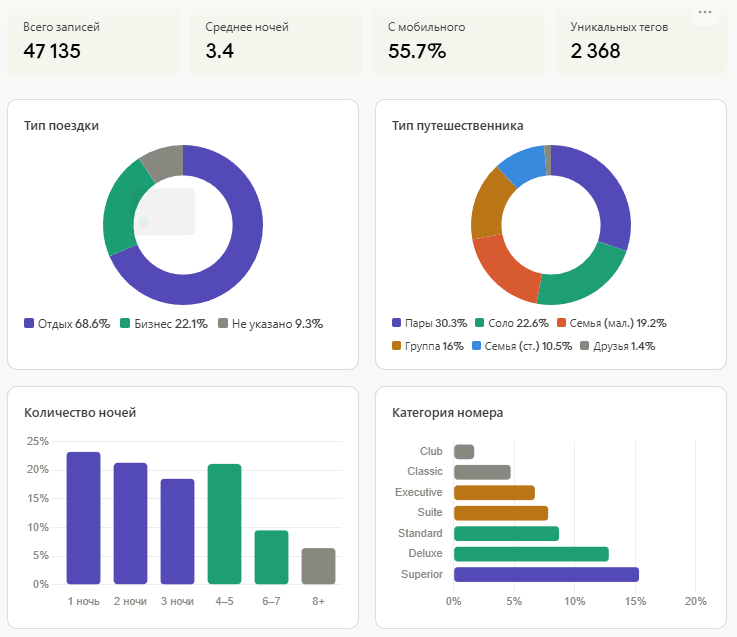

Напишем код, что бы вычленить все эти признаки.

In [102]:
def parse_line(line: str) -> list[str] | None:
    """Парсит строку вида ['Tag 1', 'Tag 2', ...] → список строк."""
    try:
        tags = ast.literal_eval(line.strip())
        return [t.strip() for t in tags if isinstance(t, str)]
    except Exception:
        return None
 
 
def extract_trip_type(tags: list[str]) -> str:
    for t in tags:
        if re.search(r'leisure', t, re.I):
            return 'Leisure'
        if re.search(r'business', t, re.I):
            return 'Business'
    return 'Unknown'
 
 
def extract_traveler_type(tags: list[str]) -> str:
    for t in tags:
        tl = t.lower()
        if 'couple' in tl:
            return 'Couple'
        if 'solo' in tl:
            return 'Solo traveler'
        if 'young children' in tl:
            return 'Family (young children)'
        if 'older children' in tl:
            return 'Family (older children)'
        if 'friends' in tl:
            return 'Travelers with friends'
        if 'group' in tl:
            return 'Group'
    return 'Unknown'
 
 
def extract_nights(tags: list[str]) -> int | None:
    for t in tags:
        m = re.search(r'Stayed\s+(\d+)\s+night', t, re.I)
        if m:
            return int(m.group(1))
    return None

# Приоритет категорий номеров (от специфичного к общему)
ROOM_CATEGORIES = [
    ('Junior Suite',  re.compile(r'junior suite', re.I)),
    ('Suite',         re.compile(r'suite', re.I)),
    ('Executive',     re.compile(r'executive', re.I)),
    ('Club',          re.compile(r'club', re.I)),
    ('Superior',      re.compile(r'superior', re.I)),
    ('Deluxe',        re.compile(r'deluxe', re.I)),
    ('Classic',       re.compile(r'classic', re.I)),
    ('Standard',      re.compile(r'standard', re.I)),
]
 
# Паттерн для определения, что тег — это номер (а не общий тег)
ROOM_HINT = re.compile(
    r'\b(room|suite|twin|double|single|triple|king|queen|studio|apartment|villa|bungalow|cabin)\b',
    re.I,
)
 
def extract_room_category(tags: list[str]) -> str:
    """Возвращает категорию номера или 'Other' / 'Unknown'."""
    room_tags = [t for t in tags if ROOM_HINT.search(t)]
    if not room_tags:
        return 'Unknown'
    for category, pattern in ROOM_CATEGORIES:
        for t in room_tags:
            if pattern.search(t):
                return category
    return 'Other'
 
 
def extract_mobile(tags: list[str]) -> int:
    return int(any('mobile device' in t.lower() for t in tags))
 
 
def extract_pet(tags: list[str]) -> int:
    return int(any('pet' in t.lower() for t in tags))

In [103]:
records = []

for idx, row in hotels.iterrows():
    tags = row['tags_list']
    if tags is None:
        continue
    
    record = {
        'index_ref': idx,
        'trip_type': extract_trip_type(tags),
        'traveler_type': extract_traveler_type(tags),
        'nights': extract_nights(tags),
        'room_category': extract_room_category(tags),
        'used_mobile': extract_mobile(tags),
        'had_pet': extract_pet(tags),
    }
    records.append(record)

In [104]:
records_df = pd.DataFrame(records)

In [105]:
cat_cols = ['trip_type', 'traveler_type', 'room_category']
for col in cat_cols:
    records_df[col] = records_df[col].astype('category')

In [106]:
hotels = hotels.merge(records_df, left_index=True, right_on='index_ref', how='left').drop('index_ref', axis=1)

In [107]:
for col in cat_cols:
    print(f"Группа {col}:")
    print(hotels.groupby(col)['reviewer_score'].mean().sort_values(ascending=False).round(2))
    print()

Группа trip_type:
trip_type
Leisure     8.49
Unknown     8.14
Business    7.97
Name: reviewer_score, dtype: float64

Группа traveler_type:
traveler_type
Couple                     8.51
Travelers with friends     8.51
Group                      8.45
Family (older children)    8.44
Family (young children)    8.30
Solo traveler              8.13
Name: reviewer_score, dtype: float64

Группа room_category:
room_category
Classic         8.60
Junior Suite    8.57
Superior        8.55
Suite           8.55
Deluxe          8.47
Club            8.39
Executive       8.37
Other           8.37
Unknown         8.36
Standard        8.16
Name: reviewer_score, dtype: float64



In [108]:
hotels['nights'] = hotels['nights'].fillna(hotels['nights'].median()).astype(int)

In [109]:
hotels['extreme_nights'] = hotels['nights'].apply(lambda x: 1 if x > 12 else 0)

In [110]:
hotels.groupby('extreme_nights')['reviewer_score'].mean().sort_values(ascending=False).round(2)

extreme_nights
0    8.40
1    7.89
Name: reviewer_score, dtype: float64

In [111]:
hotels['days_since_review'] = hotels['days_since_review'].apply(lambda x: int(x.split()[0]) if isinstance(x, str) else x)

In [112]:
hotels['days_since_review'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    386803.000000
mean        354.387978
std         208.975174
min           0.000000
50%         353.000000
75%         527.000000
90%         653.000000
95%         693.000000
99%         723.000000
max         730.000000
Name: days_since_review, dtype: float64

Эмпирическим путём подсчитал число для days_since_review при котором наблюдается наибольшая разница в средней оценке.

In [113]:
hotels['is_oldest_reviews'] = hotels['days_since_review'].apply(lambda x: 1 if x > 620 else 0)

In [114]:
hotels.groupby('is_oldest_reviews')['reviewer_score'].mean().sort_values(ascending=False).round(2)

is_oldest_reviews
0    8.41
1    8.28
Name: reviewer_score, dtype: float64

H0: Оценки для старых ревью не отличаются от новых.  
H1: Оценки для старых и новых ревью отличаются.  

In [115]:
shapiro_test(hotels[hotels['is_oldest_reviews'] == 1]['reviewer_score'])
shapiro_test(hotels[hotels['is_oldest_reviews'] == 0]['reviewer_score'])

Данные распределены не нормально
Данные распределены не нормально


c:\Dev\SkillFactory\PROJECT-3.EDA_+_Feature Engineering\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 53474.
  res = hypotest_fun_out(*samples, **kwds)
c:\Dev\SkillFactory\PROJECT-3.EDA_+_Feature Engineering\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 333329.
  res = hypotest_fun_out(*samples, **kwds)


In [116]:
is_oldest_groups = [
    hotels[hotels['is_oldest_reviews'] == 1]['reviewer_score'],
    hotels[hotels['is_oldest_reviews'] == 0]['reviewer_score'],
]

_, p = mannwhitneyu(*is_oldest_groups)

if p > 0.05:
    print("У нас нет оснований отвергнуть нулевую гипотезу")
else:
    print("Отвергаем нулевую гипотезу в пользу альтернативной")

Отвергаем нулевую гипотезу в пользу альтернативной


Поработаем ещё с отзывами и вычислим их сантимент.

In [117]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

hotels['sentiment_negative'] = hotels['negative_review'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)
hotels['sentiment_positive'] = hotels['positive_review'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)
hotels['sentiment_gap'] = hotels['sentiment_positive'] - hotels['sentiment_negative']

Проведём работу с признаками. Удалим ненужные и приведём некоторые к правильным типам.

In [118]:
hotels = hotels.drop(columns=['reviewer_nationality'])

In [119]:
drop_columns = ['hotel_address', 'review_date', 'negative_review', 'positive_review', 'tags', 'tags_list', 'hotel_name', 'review_date']
hotels = hotels.drop(columns=drop_columns)

In [120]:
category_cols = [
    "hotel_country",
    "hotel_capital",
    "hotel_district",
    "reviewer_region"
]

for col in category_cols:
    hotels[col] = hotels[col].astype('category')

In [121]:
hotels = hotels.replace(' ', np.nan)

Поработаем с мультиколлинеарностью. Будем брать признаки с сильной корреляцией. Больше 0.7

In [122]:
# Get correlation matrix
corr_matrix = hotels.corr(numeric_only=True)

# Create mask for upper triangle (excluding diagonal)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# Filter correlations with absolute value >= 0.7
strong_corr = corr_matrix.where(mask & (abs(corr_matrix) >= 0.7)).stack().dropna()

strong_corr_sorted = strong_corr.abs().sort_values(ascending=False)

print(f"Number of strong correlations (|correlation| >= 0.7): {len(strong_corr_sorted)}")
print("\nTop 10 strongest correlations (by absolute value):")
print(strong_corr_sorted)

Number of strong correlations (|correlation| >= 0.7): 5

Top 10 strongest correlations (by absolute value):
review_total_positive_word_counts  positive_word_count_clean    0.998998
review_total_negative_word_counts  negative_word_count_clean    0.998748
days_since_review                  review_year                  0.917355
additional_number_of_scoring       total_number_of_reviews      0.824467
review_month                       is_first_months              0.744907
dtype: float64


In [123]:
drop_cols = [
    "review_total_positive_word_counts",
    "review_total_negative_word_counts",
    "review_year",
    "total_number_of_reviews",
    "review_month",
]

hotels = hotels.drop(columns=drop_cols)

In [124]:
# Get correlation matrix
corr_matrix = hotels.corr(numeric_only=True)

# Create mask for upper triangle (excluding diagonal)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# Filter correlations with absolute value >= 0.7
strong_corr = corr_matrix.where(mask & (abs(corr_matrix) >= 0.7)).stack().dropna()

strong_corr_sorted = strong_corr.abs().sort_values(ascending=False)

print(f"Number of strong correlations (|correlation| >= 0.7): {len(strong_corr_sorted)}")
print("\nTop 10 strongest correlations (by absolute value):")
print(strong_corr_sorted)

Number of strong correlations (|correlation| >= 0.7): 0

Top 10 strongest correlations (by absolute value):
Series([], dtype: float64)


In [125]:
str_cols = [
    'hotel_city',
    'postcode'
]

for col in str_cols:
    hotels[col] = hotels[col].astype('category')

In [126]:
cat_cols = []

for column in hotels.columns:
    if hotels[column].dtype == 'category':
        cat_cols.append(column)
        print(column)
        print(hotels[column].unique())

hotel_country
['United Kingdom', 'France', 'Netherlands', 'Italy', 'Austria', 'Spain']
Categories (6, str): ['Austria', 'France', 'Italy', 'Netherlands', 'Spain', 'United Kingdom']
hotel_capital
['London', 'Paris', 'Amsterdam', 'Rome', 'Vienna', 'Madrid']
Categories (6, str): ['Amsterdam', 'London', 'Madrid', 'Paris', 'Rome', 'Vienna']
hotel_district
['West End', 'Holborn & Covent Garden', 'Paris', 'West', 'Municipio 4', ..., 'Montrouge', 'Morivione', 'Gury', 'Alsergrund', 'Ottakring']
Length: 241
Categories (241, str): ['17th Arrondissement', '6th Arrondissement', '7th Arrondissement', 'Abbots Manor Estate', ..., 'la Maternitat i Sant Ramon', 'la Nova Esquerra de l'Eixample', 'la Vila de Gracia', 'les Corts']
hotel_city
['London', 'Paris', 'Amsterdam', 'Milan', 'Vienna', 'Barcelona']
Categories (6, str): ['Amsterdam', 'Barcelona', 'London', 'Milan', 'Paris', 'Vienna']
postcode
['W1J', 'WC1B', '75006', '75019', '1014', ..., '1052', '1018', '1230', '92120', '20141']
Length: 239
Categori

In [127]:
y = hotels['reviewer_score']
y = y.astype('float')
y

0         10.0
1          6.3
2          7.5
3         10.0
4          9.6
          ... 
386798     8.8
386799     9.2
386800     8.3
386801     9.2
386802     8.8
Name: reviewer_score, Length: 386803, dtype: float64

In [128]:
encoded_cols = pd.DataFrame()

In [129]:
bin_encoder = ce.BinaryEncoder(cols=['hotel_district', 'postcode'])
type_bin = bin_encoder.fit_transform(hotels[['hotel_district', 'postcode']])

In [130]:
encoded_cols = pd.concat([encoded_cols, type_bin], axis=1)

In [131]:
hotels = pd.concat([hotels, type_bin], axis=1)

In [132]:
encoder = ce.OneHotEncoder(cols=['hotel_country', 'hotel_capital', 'traveler_type', 'hotel_city', 'reviewer_region', 'trip_type', 'room_category'])
type_bin = encoder.fit_transform(hotels[['hotel_country', 'hotel_capital', 'traveler_type', 'hotel_city', 'reviewer_region', 'trip_type', 'room_category']])
hotels = pd.concat([hotels, type_bin], axis=1)

In [133]:
cols_to_drop = hotels.select_dtypes(include=['category']).columns
hotels = hotels.drop(columns=cols_to_drop)

In [134]:
cols_with_nulls = hotels.columns[hotels.isnull().any()].tolist()

In [135]:
cols_with_nulls

[]

In [136]:
# Разбиваем датафрейм на части, необходимые для обучения и тестирования модели  
# Х - данные с информацией об отелях, у - целевая переменная (рейтинги отелей)  
X = hotels.drop(['reviewer_score'], axis = 1)  
y = hotels['reviewer_score'] 

In [137]:
# Загружаем специальный инструмент для разбивки:  
from sklearn.model_selection import train_test_split  

In [138]:
# Наборы данных с меткой "train" будут использоваться для обучения модели, "test" - для тестирования.  
# Для тестирования мы будем использовать 25% от исходного датасета.  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [139]:
# Импортируем необходимые библиотеки:  
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели  
from sklearn import metrics # инструменты для оценки точности модели  
  
# Создаём модель  
regr = RandomForestRegressor(n_estimators=100)  
      
# Обучаем модель на тестовом наборе данных  
regr.fit(X_train, y_train)  
      
# Используем обученную модель для предсказания рейтинга отелей в тестовой выборке.  
# Предсказанные значения записываем в переменную y_pred  
y_pred = regr.predict(X_test)  


In [140]:
# Сравниваем предсказанные значения (y_pred) с реальными (y_test), и смотрим насколько они отличаются  
# Метрика называется Mean Absolute Percentage Error (MAPE) и показывает среднюю абсолютную процентную ошибку предсказанных значений от фактических.  
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))

MAPE: 0.11955075500499038


In [141]:
importances = pd.Series(
    regr.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=False)

print(importances.head(20))

positive_ratio                                0.328533
sentiment_positive                            0.067688
average_score                                 0.064955
has_positive                                  0.049087
sentiment_negative                            0.046469
days_since_review                             0.038123
sentiment_gap                                 0.033873
additional_number_of_scoring                  0.025076
distance_to_city_center                       0.024099
negative_word_count_clean                     0.023971
lat                                           0.022711
lng                                           0.021836
total_number_of_reviews_reviewer_has_given    0.020377
negative_review_strength                      0.017906
positive_word_count_clean                     0.017218
nights                                        0.012280
negative_summary                              0.010836
bad_staff                                     0.006777
positive_s